# REGRESSION PROJECT NO: 01
## Electricity Consumption Prediction - End-to-End Machine Learning Project

### Step 1: Understanding the Dataset
The Electricity Consumption dataset is a regression dataset used for predicting daily electricity usage (in kWh) based on various environmental and building features.

**Dataset Features:**
- **Temperature**: Ambient outdoor temperature in °C
- **Humidity**: Relative humidity percentage (%)
- **BuildingArea**: Building area in square feet
- **Occupants**: Number of occupants in the building
- **ApplianceCount**: Number of active electrical appliances
- **IsWeekend**: Weekend flag (1 = Weekend, 0 = Weekday)
- **AC_Usage_Hours**: Daily Air Conditioner usage in hours
- **ElectricityConsumption**: Target variable (Daily electricity consumption in kWh)


### Step 2: Importing Necessary Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle

### Step 3: Loading the Dataset

In [2]:
# Load the Electricity Consumption dataset from CSV
data = pd.read_csv('electricity_consumption.csv')

# Display the first 5 rows of the dataset
data.head()

,Temperature,Humidity,BuildingArea,Occupants,ApplianceCount,IsWeekend,AC_Usage_Hours,ElectricityConsumption
0,25.11,32.96,1546.82,3,3,1,9.44,77.05
1,40.67,57.93,1487.92,9,18,1,11.52,121.96
2,34.76,81.11,4125.02,5,13,0,7.25,108.82
3,31.16,71.26,1498.18,8,15,0,8.20,96.45
4,19.21,76.46,1587.80,7,12,0,3.39,66.86


### Step 4: Data Exploration and Cleaning

In [3]:
# Display information about the dataset such as column names, data types, and non-null counts
data.info()

# Check for any missing values in each column of the dataset
data.isnull().sum()

# Generate descriptive statistics for all numerical features
data.describe().transpose()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature             1000 non-null   float64
 1   Humidity                1000 non-null   float64
 2   BuildingArea            1000 non-null   float64
 3   Occupants               1000 non-null   int64  
 4   ApplianceCount          1000 non-null   int64  
 5   IsWeekend               1000 non-null   int64  
 6   AC_Usage_Hours          1000 non-null   float64
 7   ElectricityConsumption  1000 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 62.6 KB


,count,mean,std,min,25%,50%,75%,max
Temperature,1000.0,28.23685,7.887737,15.13,21.3750,28.415,35.1000,41.99
Humidity,1000.0,55.49110,20.453302,20.23,36.8725,56.310,73.2325,89.96
BuildingArea,1000.0,2509.62287,1162.696768,500.05,1545.4025,2502.455,3536.4125,4491.28
Occupants,1000.0,5.00900,2.580616,1.00,3.0000,5.000,7.0000,9.00
ApplianceCount,1000.0,11.23800,4.936165,3.00,7.0000,12.000,16.0000,19.00
IsWeekend,1000.0,0.27800,0.448238,0.00,0.0000,0.000,1.0000,1.00
AC_Usage_Hours,1000.0,7.14433,2.851184,0.00,5.1700,7.185,9.1225,16.86
ElectricityConsumption,1000.0,88.80042,17.432454,39.94,75.6075,89.715,100.6300,131.80


### Step 5: Exploratory Data Analysis (EDA)

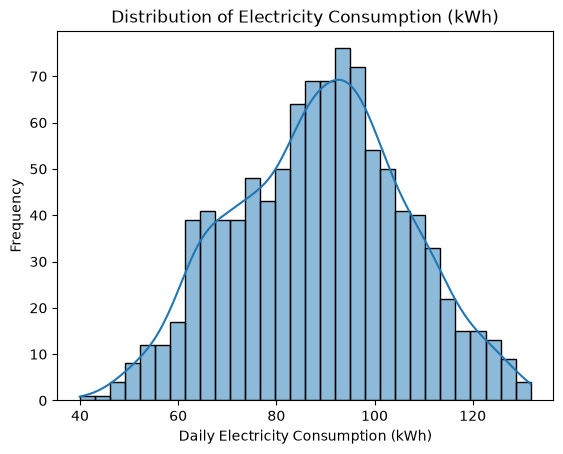

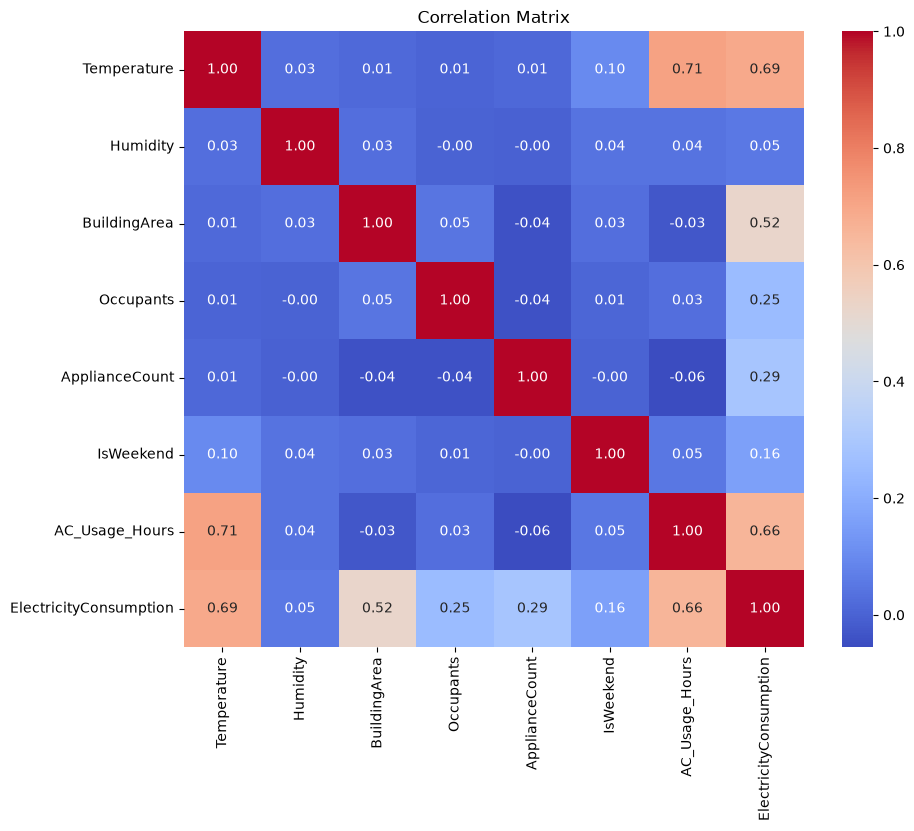

In [4]:
# Plot the distribution of the target variable 'ElectricityConsumption'
sns.histplot(data['ElectricityConsumption'], bins=30, kde=True)
plt.title('Distribution of Electricity Consumption (kWh)')
plt.xlabel('Daily Electricity Consumption (kWh)')
plt.ylabel('Frequency')
plt.show()

# Plot the correlation matrix to see how features relate to each other and to the target
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Step 6: Data Preprocessing

#### 1. Splitting Data into Features and Target

In [5]:
# Separate features (independent variables) and target (dependent variable)
X = data.drop(columns=['ElectricityConsumption']) # Features
y = data['ElectricityConsumption'] # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#### 2. Feature Scaling

In [6]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training features and transform them
X_train = scaler.fit_transform(X_train)

# Use the same scaler to transform the test features
X_test = scaler.transform(X_test)

### Step 7: Model Training & Evaluation

#### 1. Defining Models

In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

#### 2. Training & Evaluating Models

In [8]:
results = [] # To store evaluation metrics for each model

for model_name, model in models.items():
    model.fit(X_train, y_train) # Train the model using training data
    y_pred = model.predict(X_test) # Predict target values for test data
    
    # Evaluate model performance
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Save results in list
    results.append({
        'Model': model_name,
        'MSE': mse,
        'MAE': mae,
        'R2 Score': r2
    })

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results)
print(results_df)

               Model        MSE       MAE  R2 Score
0  Linear Regression   5.802876  1.959565  0.981014
1   Ridge Regression   5.794804  1.957529  0.981041
2   Lasso Regression   5.729323  1.936402  0.981255
3      Decision Tree  77.943181  7.315620  0.744987
4      Random Forest  22.507787  3.676034  0.926359


### Step 8: Saving the Best Model

In [9]:
import pickle

# Step 1: Define and Train the Best Model
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

# Step 2: Save the Trained Model to a Pickle File
with open('best_model.pkl', 'wb') as model_file:
    pickle.dump(best_model, model_file)

# Step 3: Save the Scaler Used During Preprocessing
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print('Best model and Scaler saved successfully!')

Best model and Scaler saved successfully!


### Step 9: Deploying with Streamlit:
#### Creating a Streamlit App

In [10]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle
import io
import plotly.express as px
import pandas as pd
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont

# Register Devanagari TTF Font for ReportLab if available
try:
    pdfmetrics.registerFont(TTFont('Nirmala', 'C:/Windows/Fonts/Nirmala.ttc', subfontIndex=0))
    PDF_FONT = 'Nirmala'
except Exception:
    PDF_FONT = 'Helvetica'

# Set page configuration
st.set_page_config(page_title="VoltIQ - Smart AI Energy & Solar Audit", page_icon="⚡", layout="wide")

# Custom CSS styling for premium look & intuitive UI
st.markdown("""
    <style>
    /* Metric Card Styling */
    [data-testid="stMetricValue"] {
        font-weight: 800 !important;
        font-size: 1.6rem !important;
    }
    .main-guide-card {
        background: linear-gradient(135deg, rgba(245, 158, 11, 0.1), rgba(59, 130, 246, 0.1));
        border: 1px solid rgba(245, 158, 11, 0.3);
        border-radius: 12px;
        padding: 16px;
        margin-bottom: 20px;
    }
    .step-badge {
        background-color: #F59E0B;
        color: #000000;
        font-weight: bold;
        padding: 2px 8px;
        border-radius: 6px;
        font-size: 0.85rem;
    }
    </style>
""", unsafe_allow_html=True)

# Function to make prediction using the saved model and scaler
def predict_electricity_consumption(input_features):
    with open('best_model.pkl', 'rb') as model_file:
        model = pickle.load(model_file)
    with open('scaler.pkl', 'rb') as scaler_file:
        scaler = pickle.load(scaler_file)
        
    input_array = np.array(input_features).reshape(1, -1)
    scaled_input = scaler.transform(input_array)
    prediction = model.predict(scaled_input)
    return max(0.5, prediction[0])

# Multilingual PDF Translation Dictionary
PDF_TRANSLATIONS = {
    'English': {
        'title': '⚡ ELECTRICITY CONSUMPTION & SOLAR AUDIT STATEMENT',
        'subtitle': 'Official System-Generated Energy Statement & Sustainability Report',
        'stmt_id': 'Statement ID',
        'date': 'Date',
        'area': 'Property Area',
        'occupants': 'Occupants',
        'temp': 'Ambient Temp',
        'ac_hours': 'AC Usage',
        'tariff_rate': 'Tariff Rate',
        'weekend': 'Weekend Flag',
        'sec1_title': '📊 1. Monthly Electricity Bill Breakdown',
        'particulars': 'Particulars',
        'val': 'Calculated Value',
        'daily_kwh': 'Daily Energy Consumption',
        'monthly_kwh': 'Monthly Energy Consumed (30 Days)',
        'applicable_rate': 'Applicable Tariff Rate',
        'monthly_bill': 'ESTIMATED MONTHLY ELECTRICITY BILL',
        'yearly_bill': 'Estimated Annual Electricity Expense',
        'sec2_title': '🍃 2. Carbon Footprint & Environmental Impact',
        'env_metric': 'Environmental Metric',
        'impact_level': 'Impact Level',
        'monthly_co2': 'Monthly CO₂ Grid Emissions',
        'annual_co2': 'Annual CO₂ Grid Emissions',
        'trees_saved': 'Equivalent Trees Saved per Year with Solar',
        'sec3_title': '☀️ 3. Solar Panel Investment & Payback Analysis',
        'solar_param': 'Solar Parameter',
        'solar_val': 'Value / Estimate',
        'rec_capacity': 'Recommended Solar Capacity',
        'gross_cost': 'Estimated Gross Solar System Cost',
        'subsidy': 'Est. Govt Subsidy (PM Surya Ghar)',
        'net_cost': 'Net Capital Outlay (After Subsidy)',
        'payback': 'Estimated Payback Period',
        'solar_roi': 'Annual Return on Investment (ROI)',
        'footer': 'Powered by Rahul Mahanavar Software',
        'btn_label': '📥 Download PDF Statement (English)'
    },
    'मराठी (Marathi)': {
        'title': '⚡ वीज वापर आणि सौर ऊर्जा तपासणी अहवाल',
        'subtitle': 'अधिकृत सिस्टीम-जनरेटेड ऊर्जा विवरणपत्र आणि पर्यावरण अहवाल',
        'stmt_id': 'अहवाल आयडी',
        'date': 'दिनांक',
        'area': 'इमारतीचे क्षेत्रफळ',
        'occupants': 'घरातील व्यक्ती',
        'temp': 'तापमान',
        'ac_hours': 'एसी वापर',
        'tariff_rate': 'विजेचा दर',
        'weekend': 'वीकेंड स्थिती',
        'sec1_title': '📊 १. मासिक वीज बिल तपशील',
        'particulars': 'तपशील',
        'val': 'गणित मूल्य',
        'daily_kwh': 'दैनंदिन वीज वापर',
        'monthly_kwh': 'मासिक एकूण वीज वापर (३० दिवस)',
        'applicable_rate': 'लागू विजेचा दर',
        'monthly_bill': 'अंदाजे मासिक वीज बिल',
        'yearly_bill': 'अंदाजे वार्षिक वीज खर्च',
        'sec2_title': '🍃 २. कार्बन फूटप्रिंट आणि पर्यावरण परिणाम',
        'env_metric': 'पर्यावरणीय निर्देशांक',
        'impact_level': 'परिणाम पातळी',
        'monthly_co2': 'मासिक CO₂ कार्बन उत्सर्जन',
        'annual_co2': 'वार्षिक CO₂ कार्बन उत्सर्जन',
        'trees_saved': 'सोलाअरमुळे वाचणारी वार्षिक झाडे',
        'sec3_title': '☀️ ३. सौर ऊर्जा गुंतवणूक आणि परतावा विश्लेषण',
        'solar_param': 'सौर ऊर्जा घटक',
        'solar_val': 'मूल्य / अंदाज',
        'rec_capacity': 'शिफारस केलेली सौर ऊर्जा क्षमता',
        'gross_cost': 'एकूण सोलाअर सिस्टीम खर्च',
        'subsidy': 'सरकारी सबसिडी (PM Surya Ghar)',
        'net_cost': 'निव्वळ गुंतवणूक (सबसिडीनंतर)',
        'payback': 'अंदाजे मुद्दल वसुली कालावधी',
        'solar_roi': 'वार्षिक गुंतवणुकीवरील परतावा (ROI)',
        'footer': 'Powered by Rahul Mahanavar Software',
        'btn_label': '📥 डाऊनलोड करा PDF विवरणपत्र (मराठी)'
    },
    'हिंदी (Hindi)': {
        'title': '⚡ बिजली खपत और सौर ऊर्जा लेखा परीक्षा विवरण',
        'subtitle': 'आधिकारिक प्रणाली-जनरेटेड ऊर्जा विवरण और पर्यावरण रिपोर्ट',
        'stmt_id': 'विवरण आईडी',
        'date': 'दिनांक',
        'area': 'भवन का क्षेत्रफल',
        'occupants': 'रहने वाले लोग',
        'temp': 'तापमान',
        'ac_hours': 'एसी उपयोग',
        'tariff_rate': 'बिजली की दर',
        'weekend': 'वीकेंड स्थिति',
        'sec1_title': '📊 १. मासिक बिजली बिल विवरण',
        'particulars': 'विवरण',
        'val': 'गणना मूल्य',
        'daily_kwh': 'दैनिक बिजली खपत',
        'monthly_kwh': 'मासिक कुल बिजली खपत (३० दिन)',
        'applicable_rate': 'लागू बिजली दर',
        'monthly_bill': 'अनुमानित मासिक बिजली बिल',
        'yearly_bill': 'अनुमानित वार्षिक बिजली खर्च',
        'sec2_title': '🍃 २. कार्बन पदचिह्न और पर्यावरण प्रभाव',
        'env_metric': 'पर्यावरण संकेतक',
        'impact_level': 'प्रभाव स्तर',
        'monthly_co2': 'मासिक CO₂ उत्सर्जन',
        'annual_co2': 'वार्षिक CO₂ उत्सर्जन',
        'trees_saved': 'सोलर से प्रतिवर्ष बचाए गए पेड़',
        'sec3_title': '☀️ ३. सौर ऊर्जा निवेश और वापसी विश्लेषण',
        'solar_param': 'सौर ऊर्जा पैरामीटर',
        'solar_val': 'मूल्य / अनुमान',
        'rec_capacity': 'अनुशंसित सौर ऊर्जा क्षमता',
        'gross_cost': 'कुल सोलर सिस्टम लागत',
        'subsidy': 'सरकारी सब्सिडी (PM Surya Ghar)',
        'net_cost': 'शुद्ध पूंजी निवेश (सब्सिडी के बाद)',
        'payback': 'अनुमानित लागत वापसी अवधि',
        'solar_roi': 'वार्षिक निवेश पर प्रतिफल (ROI)',
        'footer': 'Powered by Rahul Mahanavar Software',
        'btn_label': '📥 डाउनलोड करें PDF विवरण (हिंदी)'
    }
}

# Function to generate PDF Electricity Bill & Energy Audit Statement in Selected Language
def generate_pdf_report(data, lang='English'):
    buffer = io.BytesIO()
    doc = SimpleDocTemplate(buffer, pagesize=letter, rightMargin=30, leftMargin=30, topMargin=30, bottomMargin=30)
    styles = getSampleStyleSheet()
    
    t = PDF_TRANSLATIONS.get(lang, PDF_TRANSLATIONS['English'])
    
    title_style = ParagraphStyle(
        'TitleStyle', parent=styles['Heading1'], fontSize=16, leading=20,
        textColor=colors.HexColor('#1E3A8A'), alignment=1, fontName=PDF_FONT
    )
    subtitle_style = ParagraphStyle(
        'SubtitleStyle', parent=styles['Normal'], fontSize=9, leading=11,
        textColor=colors.HexColor('#4B5563'), alignment=1, fontName=PDF_FONT
    )
    section_heading = ParagraphStyle(
        'SectionHeading', parent=styles['Heading2'], fontSize=11, leading=14,
        textColor=colors.HexColor('#1E3A8A'), fontName=PDF_FONT, spaceBefore=8, spaceAfter=4
    )
    normal_style = ParagraphStyle(
        'NormalStyle', parent=styles['Normal'], fontSize=8.5, leading=11,
        textColor=colors.HexColor('#1F2937'), fontName=PDF_FONT
    )
    bold_style = ParagraphStyle('BoldStyle', parent=normal_style, fontName=PDF_FONT)

    elements = []
    
    # Header Banner
    elements.append(Paragraph(f"<b>{t['title']}</b>", title_style))
    elements.append(Paragraph(t['subtitle'], subtitle_style))
    elements.append(Spacer(1, 8))
    elements.append(HRFlowable(width="100%", thickness=1.5, color=colors.HexColor('#1E3A8A'), spaceBefore=1, spaceAfter=8))

    # Statement & Consumer Metadata Table
    meta_data = [
        [Paragraph(f"<b>{t['stmt_id']}:</b> EA-2026-8842", normal_style), Paragraph(f"<b>{t['date']}:</b> 23 Sep 2026", normal_style)],
        [Paragraph(f"<b>{t['area']}:</b> {data['area']} sq ft", normal_style), Paragraph(f"<b>{t['occupants']}:</b> {data['occupants']}", normal_style)],
        [Paragraph(f"<b>{t['temp']}:</b> {data['temp']} °C", normal_style), Paragraph(f"<b>{t['ac_hours']}:</b> {data['ac_hours']} Hours/Day", normal_style)],
        [Paragraph(f"<b>{t['tariff_rate']}:</b> ₹ {data['rate']:.2f} / kWh", normal_style), Paragraph(f"<b>{t['weekend']}:</b> {'Yes' if data['is_weekend']==1 else 'No'}", normal_style)]
    ]
    meta_table = Table(meta_data, colWidths=[270, 270])
    meta_table.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,-1), colors.HexColor('#F3F4F6')),
        ('PADDING', (0,0), (-1,-1), 5),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#E5E7EB')),
    ]))
    elements.append(meta_table)
    elements.append(Spacer(1, 10))

    # Section 1: Monthly Bill Breakdown (Electricity Utility Bill Style)
    elements.append(Paragraph(f"<b>{t['sec1_title']}</b>", section_heading))
    bill_data = [
        [Paragraph(f"<b>{t['particulars']}</b>", bold_style), Paragraph(f"<b>{t['val']}</b>", bold_style)],
        [Paragraph(t['daily_kwh'], normal_style), Paragraph(f"{data['daily_kwh']:.2f} kWh", normal_style)],
        [Paragraph(t['monthly_kwh'], normal_style), Paragraph(f"{data['monthly_kwh']:.1f} Units (kWh)", normal_style)],
        [Paragraph(t['applicable_rate'], normal_style), Paragraph(f"₹ {data['rate']:.2f} / kWh", normal_style)],
        [Paragraph(f"<b>{t['monthly_bill']}</b>", bold_style), Paragraph(f"<b>₹ {data['monthly_bill']:,.2f}</b>", bold_style)],
        [Paragraph(t['yearly_bill'], normal_style), Paragraph(f"₹ {data['yearly_bill']:,.2f}", normal_style)]
    ]
    bill_table = Table(bill_data, colWidths=[350, 190])
    bill_table.setStyle(TableStyle([
        ('HEADERBACKGROUND', (0,0), (-1,0), colors.HexColor('#DBEAFE')),
        ('BACKGROUND', (0,4), (-1,4), colors.HexColor('#FEF08A')),
        ('PADDING', (0,0), (-1,-1), 5),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#CBD5E1')),
    ]))
    elements.append(bill_table)
    elements.append(Spacer(1, 10))

    # Section 2: Carbon Footprint & Environmental Impact
    elements.append(Paragraph(f"<b>{t['sec2_title']}</b>", section_heading))
    carbon_data = [
        [Paragraph(f"<b>{t['env_metric']}</b>", bold_style), Paragraph(f"<b>{t['impact_level']}</b>", bold_style)],
        [Paragraph(t['monthly_co2'], normal_style), Paragraph(f"{data['monthly_co2']:.1f} kg CO₂", normal_style)],
        [Paragraph(t['annual_co2'], normal_style), Paragraph(f"{data['annual_co2']:.1f} kg CO₂", normal_style)],
        [Paragraph(f"<b>{t['trees_saved']}</b>", bold_style), Paragraph(f"<b>{data['trees_saved']} Trees 🌳</b>", bold_style)]
    ]
    carbon_table = Table(carbon_data, colWidths=[350, 190])
    carbon_table.setStyle(TableStyle([
        ('HEADERBACKGROUND', (0,0), (-1,0), colors.HexColor('#DCFCE7')),
        ('BACKGROUND', (0,3), (-1,3), colors.HexColor('#F0FDF4')),
        ('PADDING', (0,0), (-1,-1), 5),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#CBD5E1')),
    ]))
    elements.append(carbon_table)
    elements.append(Spacer(1, 10))

    # Section 3: Solar Investment & Payback Roadmap
    elements.append(Paragraph(f"<b>{t['sec3_title']}</b>", section_heading))
    solar_data = [
        [Paragraph(f"<b>{t['solar_param']}</b>", bold_style), Paragraph(f"<b>{t['solar_val']}</b>", bold_style)],
        [Paragraph(t['rec_capacity'], normal_style), Paragraph(f"<b>{data['solar_kw']} kW</b>", normal_style)],
        [Paragraph(t['gross_cost'], normal_style), Paragraph(f"₹ {data['gross_solar_cost']:,.2f}", normal_style)],
        [Paragraph(t['subsidy'], normal_style), Paragraph(f"- ₹ {data['subsidy']:,.2f}", normal_style)],
        [Paragraph(f"<b>{t['net_cost']}</b>", bold_style), Paragraph(f"<b>₹ {data['net_solar_cost']:,.2f}</b>", bold_style)],
        [Paragraph(f"<b>{t['payback']}</b>", bold_style), Paragraph(f"<b>~ {data['payback_years']:.1f} Years ⏳</b>", bold_style)],
        [Paragraph(t['solar_roi'], normal_style), Paragraph(f"{data['solar_roi']:.1f} % / yr", normal_style)]
    ]
    solar_table = Table(solar_data, colWidths=[350, 190])
    solar_table.setStyle(TableStyle([
        ('HEADERBACKGROUND', (0,0), (-1,0), colors.HexColor('#FFEDD5')),
        ('BACKGROUND', (0,4), (-1,4), colors.HexColor('#FFEDD5')),
        ('PADDING', (0,0), (-1,-1), 5),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#CBD5E1')),
    ]))
    elements.append(solar_table)
    elements.append(Spacer(1, 12))

    # Footer - Powered by Rahul Mahanavar Software
    elements.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#94A3B8'), spaceBefore=5, spaceAfter=5))
    elements.append(Paragraph(f"<b>{t['footer']}</b>", subtitle_style))
    
    doc.build(elements)
    buffer.seek(0)
    return buffer.getvalue()

# Streamlit App Header
st.title('⚡ VoltIQ - Smart AI Electricity & Solar Audit Platform')
st.markdown('Predict daily electricity usage (kWh), estimate monthly bill (₹), evaluate carbon footprint, and analyze Solar ROI & Payback period!')

# User Guidance Card right at the top
st.markdown("""
<div class="main-guide-card">
    <div style="font-weight: 700; font-size: 1.05rem; color: #F59E0B; margin-bottom: 8px;">
        💡 How to Use VoltIQ Platform / हे ॲप कसे वापरावे?
    </div>
    <div style="font-size: 0.9rem; line-height: 1.6;">
        <span class="step-badge">Step 1</span> <b>Adjust Inputs / इनपुट बदला</b>: Change Temperature, Building Area, Occupants & AC Usage on the left sidebar (<i>On Mobile: Click <b>top-left ☰ button</b></i>).<br>
        <span class="step-badge">Step 2</span> <b>Auto-Calculated Results / त्वरित निकाल</b>: View your live Electricity Consumption (kWh), Monthly Bill (₹), Solar Size (kW), & Carbon Footprint below.<br>
        <span class="step-badge">Step 3</span> <b>Download PDF Statement / अहवाल डाऊनलोड करा</b>: Select English, मराठी, or हिंदी at the bottom to download your official PDF report!
    </div>
</div>
""", unsafe_allow_html=True)

# Sidebar for User Input
st.sidebar.header('⚙️ Input Features (घराची माहिती)')
st.sidebar.write('Change parameters below to recalculate live bill & solar size:')

temp = st.sidebar.number_input('Temperature (°C)', min_value=0.0, max_value=60.0, value=25.0, step=0.5)
humidity = st.sidebar.number_input('Humidity (%)', min_value=0.0, max_value=100.0, value=50.0, step=1.0)
area = st.sidebar.number_input('Building Area (sq ft)', min_value=100.0, max_value=10000.0, value=800.0, step=50.0)
occupants = st.sidebar.number_input('Occupants Count', min_value=1, max_value=50, value=4, step=1)
appliances = st.sidebar.number_input('Appliance Count', min_value=1, max_value=50, value=5, step=1)
is_weekend = st.sidebar.selectbox('Is Weekend?', [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
ac_hours = st.sidebar.number_input('AC Usage Hours (Hours/Day)', min_value=0.0, max_value=24.0, value=0.0, step=0.5)

st.sidebar.markdown('---')
st.sidebar.header('💵 Electricity Tariff Settings')
unit_rate = st.sidebar.number_input('Electricity Rate (₹ / kWh)', min_value=1.0, max_value=25.0, value=8.0, step=0.5)

input_features = [temp, humidity, area, occupants, appliances, is_weekend, ac_hours]

# Predict button triggers explicit recalculation
btn_click = st.sidebar.button('🚀 Recalculate Now', type='primary', use_container_width=True)

# Always render live calculations (Default Auto-Run on page load)
daily_kwh = predict_electricity_consumption(input_features)
monthly_kwh = daily_kwh * 30.0
monthly_bill = monthly_kwh * unit_rate
yearly_bill = monthly_bill * 12.0

# Solar capacity calculation: 1 kW solar generates ~4 kWh per day
recommended_solar_kw = max(1.0, round(daily_kwh / 4.0, 1))

# 1. Carbon Footprint Calculations (0.82 kg CO2 per kWh)
monthly_co2 = monthly_kwh * 0.82
annual_co2 = monthly_co2 * 12.0
trees_saved = int(annual_co2 / 20.0)

# 2. Solar ROI & Payback Calculations
gross_solar_cost = recommended_solar_kw * 50000.0
subsidy = min(78000.0, 30000.0 * min(2, recommended_solar_kw) + (18000.0 if recommended_solar_kw >= 3 else 0.0))
net_solar_cost = max(10000.0, gross_solar_cost - subsidy)
payback_years = round(net_solar_cost / yearly_bill, 1) if yearly_bill > 0 else 0.0
solar_roi = round((yearly_bill / net_solar_cost) * 100.0, 1) if net_solar_cost > 0 else 0.0

# 3. Seasonal Comparison Predictions
summer_kwh = predict_electricity_consumption([min(50.0, temp + 6.0), humidity, area, occupants, appliances, is_weekend, min(24.0, ac_hours + 3.0)])
summer_bill = summer_kwh * 30.0 * unit_rate

winter_kwh = predict_electricity_consumption([max(15.0, temp - 5.0), humidity, area, occupants, appliances, is_weekend, 0.0])
winter_bill = winter_kwh * 30.0 * unit_rate

st.markdown("---")
st.subheader("📊 1. Primary Energy Prediction & Insights")

# Display 4 Main Metric Cards
c1, c2, c3, c4 = st.columns(4)
with c1:
    st.metric(label="Daily Consumption", value=f"{daily_kwh:.2f} kWh")
with c2:
    st.metric(label="Monthly Units", value=f"{monthly_kwh:.1f} Units")
with c3:
    st.metric(label="Estimated Monthly Bill", value=f"₹ {monthly_bill:,.2f}")
with c4:
    st.metric(label="Recommended Solar Size", value=f"{recommended_solar_kw} kW")

st.markdown("---")

# Detailed Impact Cards Row (Bill & Solar & Carbon)
r1_col1, r1_col2 = st.columns(2)

with r1_col1:
    st.info("### 💵 Monthly Bill & Tariff Breakdown\n"
            f"- **Daily Energy Used**: `{daily_kwh:.2f} kWh`\n"
            f"- **Monthly Energy Consumed**: `{monthly_kwh:.2f} kWh`\n"
            f"- **Tariff Rate**: `₹ {unit_rate:.2f} / kWh`\n"
            f"- **Estimated Monthly Bill**: **`₹ {monthly_bill:,.2f}`**\n"
            f"- **Estimated Yearly Bill**: **`₹ {yearly_bill:,.2f}`**\n")

with r1_col2:
    st.success("### ☀️ Solar ROI & Investment Roadmap\n"
               f"- **Recommended Capacity**: **`{recommended_solar_kw} kW`**\n"
               f"- **Gross Solar Cost**: `₹ {gross_solar_cost:,.2f}`\n"
               f"- **Est. Govt Subsidy (PM Surya Ghar)**: `- ₹ {subsidy:,.2f}`\n"
               f"- **Net Investment (After Subsidy)**: **`₹ {net_solar_cost:,.2f}`**\n"
               f"- **Payback Period**: **`~ {payback_years} Years ⏳`** *(Annual ROI: {solar_roi}%/yr)*\n")

st.markdown("---")

# Feature 1 & Feature 3 Row: Carbon Footprint & Seasonal Chart
r2_col1, r2_col2 = st.columns(2)

with r2_col1:
    st.subheader("🍃 Carbon Footprint & Environmental Impact")
    st.warning(
        f"- 🏭 **Monthly CO₂ Grid Emissions**: `{monthly_co2:.1f} kg CO₂`\n"
        f"- 💨 **Annual CO₂ Grid Emissions**: `{annual_co2:.1f} kg CO₂`\n"
        f"- 🌳 **Trees Saved Equivalent with Solar**: **`{trees_saved} Trees Saved / Year`**\n\n"
        f"💡 *Installing a `{recommended_solar_kw} kW` Solar System reduces your carbon footprint to 0 and saves {trees_saved} trees every year!*"
    )

with r2_col2:
    st.subheader("☀️ ⛅ ❄️ Seasonal Bill Comparison")
    seasonal_df = pd.DataFrame({
        'Season': ['Summer (उन्हाळा)', 'Monsoon (पावसाळा/Current)', 'Winter (हिवाळा)'],
        'Monthly Bill (₹)': [round(summer_bill, 2), round(monthly_bill, 2), round(winter_bill, 2)]
    })
    fig = px.bar(
        seasonal_df, x='Season', y='Monthly Bill (₹)', text='Monthly Bill (₹)',
        color='Season', color_discrete_sequence=['#EF4444', '#3B82F6', '#10B981'],
        title="Estimated Bill Variation Across Seasons"
    )
    fig.update_traces(texttemplate='₹ %{text:,.2f}', textposition='outside')
    fig.update_layout(showlegend=False, height=300)
    st.plotly_chart(fig, use_container_width=True)

st.markdown("---")

# Feature 4: Downloadable Multilingual PDF Electricity Bill Report
st.subheader("📄 Download Official Electricity & Solar Audit Statement (PDF)")

col_pdf1, col_pdf2 = st.columns([1, 2])
with col_pdf1:
    selected_pdf_lang = st.selectbox(
        "🌐 Select PDF Language / भाषा निवडा",
        ['English', 'मराठी (Marathi)', 'हिंदी (Hindi)'],
        index=0,
        key='pdf_lang_select'
    )

report_data = {
    'area': area,
    'occupants': occupants,
    'temp': temp,
    'ac_hours': ac_hours,
    'rate': unit_rate,
    'is_weekend': is_weekend,
    'daily_kwh': daily_kwh,
    'monthly_kwh': monthly_kwh,
    'monthly_bill': monthly_bill,
    'yearly_bill': yearly_bill,
    'monthly_co2': monthly_co2,
    'annual_co2': annual_co2,
    'trees_saved': trees_saved,
    'solar_kw': recommended_solar_kw,
    'gross_solar_cost': gross_solar_cost,
    'subsidy': subsidy,
    'net_solar_cost': net_solar_cost,
    'payback_years': payback_years,
    'solar_roi': solar_roi
}

pdf_bytes = generate_pdf_report(report_data, lang=selected_pdf_lang)
btn_label = PDF_TRANSLATIONS.get(selected_pdf_lang, {}).get('btn_label', '📥 Download PDF Statement')

with col_pdf2:
    st.markdown("<br>", unsafe_allow_html=True)
    st.download_button(
        label=btn_label,
        data=pdf_bytes,
        file_name=f"Electricity_Bill_and_Solar_Audit_Report_{selected_pdf_lang.split()[0]}.pdf",
        mime="application/pdf",
        type="primary"
    )



Overwriting app.py


To run this Streamlit app, use the following command in your terminal:
```bash
streamlit run app.py
```

### Conclusion
Explored, cleaned, and visualized the dataset.
Trained multiple regression models and evaluated them.
Deployed the best model using Streamlit.
Now users can predict daily electricity consumption via an interactive web app!